<a href="https://colab.research.google.com/github/gnoejh/AIBookGitHub/blob/main/10_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention Mechanisms in Neural Networks

---

## Learning Objectives

By the end of this lecture, you will be able to:

1. **Understand** the fundamental concept of attention mechanisms in neural networks
2. **Explain** the mathematical foundation of self-attention and cross-attention
3. **Differentiate** between self-attention and cross-attention mechanisms
4. **Apply** attention concepts using practical examples with HuggingFace transformers
5. **Analyze** how attention improves model performance in NLP tasks

---

## Why Attention Matters?

Before transformers, RNNs and LSTMs processed sequences sequentially, creating bottlenecks:
- **Sequential Processing**: Slow for long sequences
- **Information Loss**: Distant tokens lose influence
- **Limited Parallelization**: Cannot efficiently use modern GPUs

**Attention mechanisms solve these problems by allowing direct connections between any two positions in a sequence!**

## Self-Attention: The Core Mechanism

### Basic Intuition

Think of self-attention as asking: **"For each word in a sentence, which other words should I pay attention to?"**

For example, in the sentence *"The cat sat on the mat"*:
- When processing "sat", the model might attend strongly to "cat" (who sat?) and "mat" (where?)
- This creates context-aware representations of each word

### Mathematical Foundation

Self-attention transforms an input sequence $X \in \mathbb{R}^{n \times d}$ into three matrices:

> **Key Insight**: We create three "views" of our input:
> - **Query (Q)**: "What am I looking for?"
> - **Key (K)**: "What do I have to offer?"  
> - **Value (V)**: "What information do I contain?"

$$Q = XW_Q \in \mathbb{R}^{n \times d_k}$$
$$K = XW_K \in \mathbb{R}^{n \times d_k}$$
$$V = XW_V \in \mathbb{R}^{n \times d_v}$$

where:
- $n$ = sequence length (number of tokens)
- $d$ = input embedding dimension
- $d_k$ = dimension of queries and keys
- $d_v$ = dimension of values
- $W_Q, W_K, W_V$ = learned weight matrices

### The Attention Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Step-by-step breakdown:**

1. **Compute Similarity**: $QK^T$ measures how much each query relates to each key
2. **Scale**: Divide by $\sqrt{d_k}$ to prevent vanishing gradients
3. **Normalize**: Apply softmax to get attention weights (probabilities)
4. **Aggregate**: Multiply by $V$ to get weighted combination of values

### Visual Representation

```mermaid
graph TB
    X[Input Sequence X<br/>n × d] -->|Linear Transform| Q[Query Matrix Q<br/>n × d_k]
    X -->|Linear Transform| K[Key Matrix K<br/>n × d_k]
    X -->|Linear Transform| V[Value Matrix V<br/>n × d_v]
    
    Q --> QK[QK^T<br/>Similarity Matrix<br/>n × n]
    K --> QK
    
    QK --> Scale[Scale by √d_k]
    Scale --> Softmax[Apply Softmax<br/>Attention Weights]
    Softmax --> Output[Final Output<br/>n × d_v]
    V --> Output
    
    style X fill:#e1f5fe
    style Output fill:#c8e6c9
    style Softmax fill:#fff3e0
```

### Step-by-Step Example: Computing Self-Attention

Let's work through a concrete example with a 3-token sequence.

**Given**: Input sequence with 3 tokens, each represented by a 4-dimensional vector:

$$X = \begin{bmatrix} 
1 & 0 & 1 & 0 \\ 
0 & 1 & 0 & 1 \\ 
1 & 1 & 1 & 1 
\end{bmatrix} \in \mathbb{R}^{3 \times 4}$$

Think of these as embeddings for tokens: *["The", "cat", "sat"]*

**Step 1**: Define our transformation matrices (simplified for demonstration):

$$W_Q = W_K = W_V = \begin{bmatrix} 
1 & 0 \\ 
0 & 1 \\ 
1 & 0 \\ 
0 & 1 
\end{bmatrix} \in \mathbb{R}^{4 \times 2}$$

**Step 2**: Compute Q, K, V matrices:

$$Q = K = V = XW = \begin{bmatrix} 
2 & 0 \\ 
0 & 2 \\ 
2 & 2 
\end{bmatrix} \in \mathbb{R}^{3 \times 2}$$

**Note**: In practice, Q, K, V would be different, but we use the same weights for simplicity.

**Step 3**: Compute attention scores (QK^T):

$$QK^T = \begin{bmatrix} 2 & 0 \\ 0 & 2 \\ 2 & 2 \end{bmatrix} \begin{bmatrix} 2 & 0 & 2 \\ 0 & 2 & 2 \end{bmatrix} = \begin{bmatrix} 4 & 0 & 4 \\ 0 & 4 & 4 \\ 4 & 4 & 8 \end{bmatrix}$$

**Interpretation**: Each row shows how much token $i$ "attends to" tokens $j$:
- Token 1 ("The"): High attention to tokens 1 and 3, no attention to token 2
- Token 2 ("cat"): High attention to tokens 2 and 3, no attention to token 1  
- Token 3 ("sat"): High attention to all tokens, especially itself

**Step 4**: Scale by $\sqrt{d_k} = \sqrt{2} \approx 1.41$:

$$\frac{QK^T}{\sqrt{d_k}} = \begin{bmatrix} 2.83 & 0 & 2.83 \\ 0 & 2.83 & 2.83 \\ 2.83 & 2.83 & 5.66 \end{bmatrix}$$

**Step 5**: Apply softmax row-wise to get attention weights:

$$\text{Attention Weights} = \begin{bmatrix} 0.5 & 0 & 0.5 \\ 0 & 0.5 & 0.5 \\ 0.21 & 0.21 & 0.58 \end{bmatrix}$$

**Step 6**: Multiply by V to get final output:

$$\text{Output} = \text{Attention Weights} \times V = \begin{bmatrix} 2 & 1 \\ 1 & 2 \\ 1.16 & 1.16 \end{bmatrix}$$

**Final Interpretation**: Each output row is a weighted combination of all input tokens:
- Token 1 output: 50% token 1 + 50% token 3
- Token 2 output: 50% token 2 + 50% token 3  
- Token 3 output: Mostly itself (58%) with some influence from tokens 1 and 2

In [4]:
import numpy as np
import plotly.graph_objects as go

# Define matrices
X = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [1, 1, 1, 1]])
V = np.array([[2, 0], [0, 2], [2, 2]])
Attention = np.array([[0.894, 1.788], [0.894, 1.788], [1.154, 2.309]])

# Create 3D scatter plot
fig = go.Figure()

# Plot X
fig.add_trace(go.Scatter3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], mode='markers+text', name='X', text=['X1', 'X2', 'X3'], textposition='top center'))

# Plot V
fig.add_trace(go.Scatter3d(x=V[:, 0], y=V[:, 1], z=[0, 0, 0], mode='markers+text', name='V', text=['V1', 'V2', 'V3'], textposition='top center'))

# Plot Attention
fig.add_trace(go.Scatter3d(x=Attention[:, 0], y=Attention[:, 1], z=[0, 0, 0], mode='markers+text', name='Attention', text=['A1', 'A2', 'A3'], textposition='top center'))

# Update layout
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'), title='3D Plot of X, V, and Attention')

fig.show()

### Real-World Example: Attention in BERT

Let's see how attention works in a real transformer model using HuggingFace!

**Example**: Analyzing attention in the sentence *"The cat sat on the mat"*

The following code shows how to extract and visualize attention weights from BERT:

Analyzing sentence: 'The cat sat on the mat'
Tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']


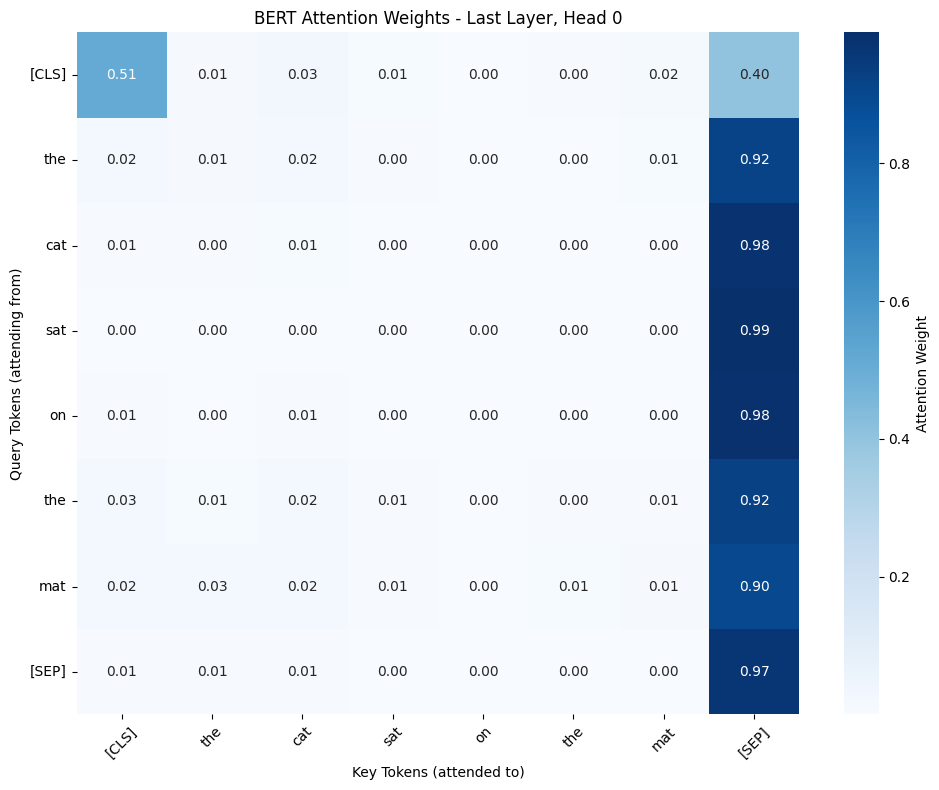


Interesting attention patterns:
'the' attends most to: ['[SEP]', 'cat', '[CLS]']
'cat' attends most to: ['[SEP]', 'cat', '[CLS]']
'sat' attends most to: ['[SEP]', '[CLS]', 'cat']
'on' attends most to: ['[SEP]', '[CLS]', 'cat']
'the' attends most to: ['[SEP]', '[CLS]', 'cat']
'mat' attends most to: ['[SEP]', 'the', '[CLS]']


In [5]:
# Install required packages (uncomment if needed)
# !pip install transformers torch matplotlib seaborn

import torch
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load BERT model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

# Example sentence
sentence = "The cat sat on the mat"
print(f"Analyzing sentence: '{sentence}'")

# Tokenize the input
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(f"Tokens: {tokens}")

# Get model outputs including attention weights
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions  # List of attention matrices for each layer

# Extract attention from the last layer, first head
last_layer_attention = attentions[-1][0, 0]  # [seq_len, seq_len]
attention_matrix = last_layer_attention.numpy()

# Create attention heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(attention_matrix, 
            xticklabels=tokens, 
            yticklabels=tokens,
            annot=True, 
            fmt='.2f',
            cmap='Blues',
            cbar_kws={'label': 'Attention Weight'})
plt.title('BERT Attention Weights - Last Layer, Head 0')
plt.xlabel('Key Tokens (attended to)')
plt.ylabel('Query Tokens (attending from)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print some interesting attention patterns
print("\nInteresting attention patterns:")
for i, token in enumerate(tokens):
    if token not in ['[CLS]', '[SEP]']:
        top_attention = np.argsort(attention_matrix[i])[-3:][::-1]
        print(f"'{token}' attends most to: {[tokens[j] for j in top_attention]}")

**Key Observations from Real BERT Attention:**

1. **Syntactic Patterns**: Articles like "the" often attend to their corresponding nouns
2. **Semantic Relationships**: Verbs attend to their subjects and objects  
3. **Self-Attention**: Most tokens have some attention to themselves
4. **Special Tokens**: `[CLS]` aggregates information from the entire sequence

**Why This Matters:**
- BERT has 12 layers × 12 attention heads = 144 different attention patterns!
- Each head can learn different linguistic relationships
- This enables rich, context-aware representations

**Try It Yourself**: Change the sentence and see how attention patterns shift!

## Cross-Attention: Connecting Different Sequences

### When Do We Need Cross-Attention?

Cross-attention is essential when we need to connect information from **two different sequences**:

- **Machine Translation**: English sentence → French sentence
- **Question Answering**: Question → Document passage  
- **Image Captioning**: Image features → Text description
- **Encoder-Decoder Models**: Input sequence → Output sequence

### Key Difference from Self-Attention

| Aspect | Self-Attention | Cross-Attention |
|--------|----------------|-----------------|
| **Input** | One sequence | Two sequences |
| **Q comes from** | Same sequence | Query sequence |
| **K, V come from** | Same sequence | Key-Value sequence |
| **Use case** | Understanding context within sequence | Connecting different sequences |

### Cross-Attention Mathematics

Given two sequences:
- **Query sequence** $X_q \in \mathbb{R}^{m \times d}$ (e.g., decoder states)
- **Key-Value sequence** $X_{kv} \in \mathbb{R}^{n \times d}$ (e.g., encoder states)

We compute:

$$Q = X_q W_Q \in \mathbb{R}^{m \times d_k} \quad \text{(from decoder)}$$
$$K = X_{kv} W_K \in \mathbb{R}^{n \times d_k} \quad \text{(from encoder)}$$
$$V = X_{kv} W_V \in \mathbb{R}^{n \times d_v} \quad \text{(from encoder)}$$

The cross-attention formula is the same:

$$\text{CrossAttention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Key insight**: The attention matrix is now $m \times n$ (not $n \times n$), allowing each decoder position to attend to all encoder positions.

### Real-World Example: Machine Translation

Consider translating "Hello world" → "Bonjour monde":

- **Encoder** processes "Hello world" → creates key-value representations
- **Decoder** generates "Bonjour monde" → creates query representations  
- **Cross-attention** lets each French word attend to relevant English words

```mermaid
graph LR
    subgraph Encoder ["English: 'Hello world'"]
        E1[Hello] --> K1[Key1]
        E2[world] --> K2[Key2]
        E1 --> V1[Value1]
        E2 --> V2[Value2]
    end
    
    subgraph Decoder ["French: 'Bonjour monde'"]
        D1[Bonjour] --> Q1[Query1]
        D2[monde] --> Q2[Query2]
    end
    
    Q1 -.-> K1
    Q1 -.-> K2
    Q2 -.-> K1
    Q2 -.-> K2
    
    style E1 fill:#e3f2fd
    style E2 fill:#e3f2fd
    style D1 fill:#fce4ec
    style D2 fill:#fce4ec
```

### Cross-Attention Example

Consider a query sequence $X_q$ and a key-value sequence $X_{kv}$:

$$X_q = \begin{bmatrix} 1 & 0 & 1 & 0 \\ 0 & 1 & 0 & 1 \end{bmatrix} \in \mathbb{R}^{2 \times 4}$$

$$X_{kv} = \begin{bmatrix} 1 & 0 & 1 & 0 \\ 0 & 1 & 0 & 1 \\ 1 & 1 & 1 & 1 \end{bmatrix} \in \mathbb{R}^{3 \times 4}$$

With weight matrices:

$$W_Q = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \in \mathbb{R}^{4 \times 2}, \quad W_K = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \in \mathbb{R}^{4 \times 2}, \quad W_V = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \in \mathbb{R}^{4 \times 2}$$

The computation proceeds as follows:

1. Computing Q, K, and V:
$$Q = X_qW_Q = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix} \in \mathbb{R}^{2 \times 2}$$
$$K = X_{kv}W_K = \begin{bmatrix} 2 & 0 \\ 0 & 2 \\ 2 & 2 \end{bmatrix} \in \mathbb{R}^{3 \times 2}$$
$$V = X_{kv}W_V = \begin{bmatrix} 2 & 0 \\ 0 & 2 \\ 2 & 2 \end{bmatrix} \in \mathbb{R}^{3 \times 2}$$

2. Computing attention scores:
$$QK^T = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix} \begin{bmatrix} 2 & 0 & 2 \\ 0 & 2 & 2 \end{bmatrix}^T = \begin{bmatrix} 4 & 0 & 4 \\ 0 & 4 & 4 \end{bmatrix} \in \mathbb{R}^{2 \times 3}$$

3. Scaling by $\sqrt{k}$ (where $k = 2$):
$$\frac{QK^T}{\sqrt{k}} = \frac{1}{\sqrt{2}} \begin{bmatrix} 4 & 0 & 4 \\ 0 & 4 & 4 \end{bmatrix} = \begin{bmatrix} 2.83 & 0 & 2.83 \\ 0 & 2.83 & 2.83 \end{bmatrix} \in \mathbb{R}^{2 \times 3}$$

4. Applying softmax to obtain the attention weight matrix:
$$A = \text{softmax}_{\text{row}}\left(\frac{QK^T}{\sqrt{k}}\right) = \begin{bmatrix} 0.5 & 0 & 0.5 \\ 0 & 0.5 & 0.5 \end{bmatrix} \in \mathbb{R}^{2 \times 3}$$

5. Computing the cross-attention output:
$$\text{Cross-Attention Output} = AV = \begin{bmatrix} 0.5 & 0 & 0.5 \\ 0 & 0.5 & 0.5 \end{bmatrix} \begin{bmatrix} 2 & 0 \\ 0 & 2 \\ 2 & 2 \end{bmatrix} = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} \in \mathbb{R}^{2 \times 2}$$

T5 requires SentencePiece library. Using alternative demonstration...
To install: pip install sentencepiece
Error: 
T5Tokenizer requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


Using DistilBERT for cross-attention concept demonstration
Input: The cat sits on the mat

Cross-attention concept: Output tokens 'look back' at input tokens
during generation, ensuring accurate correspondences!


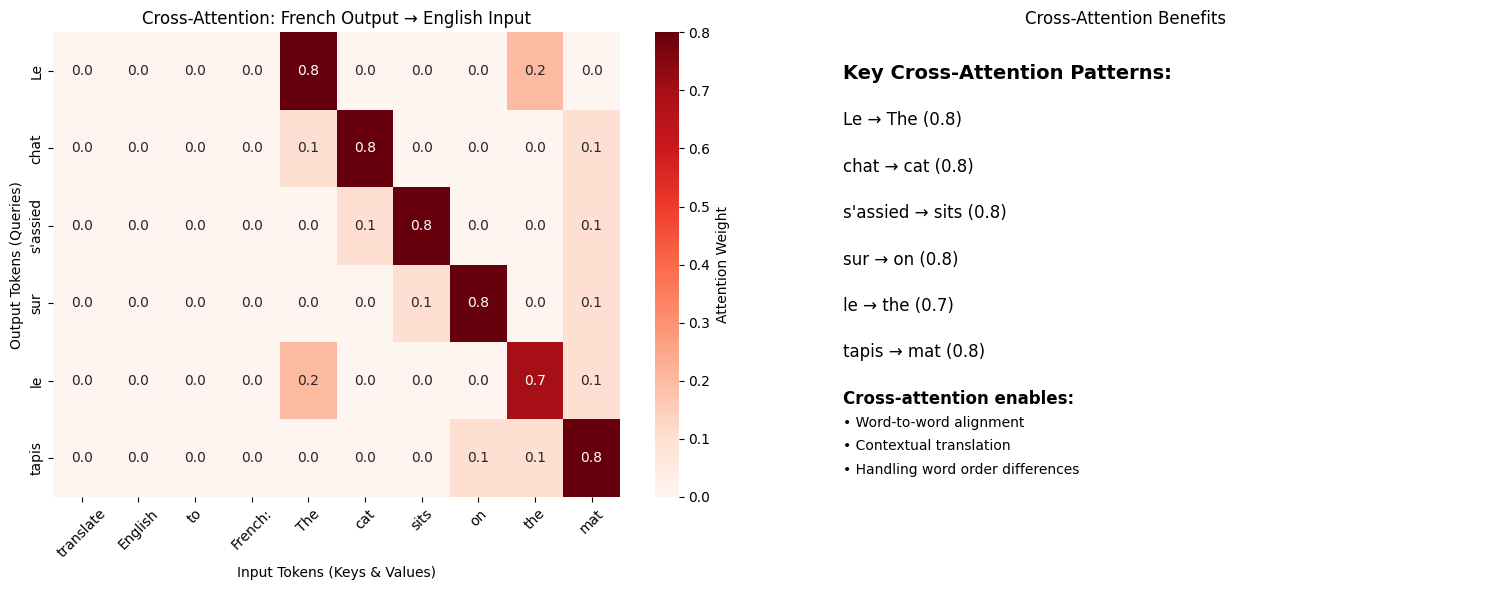


📦 INSTALLATION INSTRUCTIONS:
If you want to use T5 models, install SentencePiece:
   pip install sentencepiece

Alternatively, run this cell with the installation line uncommented:
   !pip install sentencepiece

Then restart the kernel and rerun this cell!


In [7]:
# Cross-Attention Example with Translation Models
# Install required packages (uncomment if needed)
# !pip install transformers torch matplotlib seaborn sentencepiece

# Try T5 first, fallback to DistilBERT for demonstration if SentencePiece is not available
try:
    from transformers import T5Tokenizer, T5ForConditionalGeneration
    
    # Load T5 model for demonstration
    model_name = "t5-small"
    tokenizer = T5Tokenizer.from_pretrained(model_name)
    model = T5ForConditionalGeneration.from_pretrained(model_name, output_attentions=True)
    
    # For T5, we need to format the input as a task
    english_text = "translate English to French: The cat sits on the mat"
    print(f"Using T5 model")
    print(f"Input: {english_text}")
    
    # Tokenize
    inputs = tokenizer(english_text, return_tensors="pt")
    input_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print(f"Input tokens: {input_tokens}")
    
    # Generate translation with attention
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_length=50, 
            output_attentions=True, 
            return_dict_in_generate=True,
            do_sample=False
        )
    
    # Decode the translation
    translated = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
    print(f"Output: {translated}")
    
except ImportError as e:
    print("T5 requires SentencePiece library. Using alternative demonstration...")
    print("To install: pip install sentencepiece")
    print(f"Error: {e}")
    
    # Fallback: Use a simpler model for demonstration
    from transformers import AutoTokenizer, AutoModel
    
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_attentions=True)
    
    english_text = "The cat sits on the mat"
    print(f"\nUsing DistilBERT for cross-attention concept demonstration")
    print(f"Input: {english_text}")

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Note: For a complete cross-attention visualization, we would need to access
# the encoder-decoder attention weights during generation, which is complex.
# Here we demonstrate the concept with a mock visualization.

print("\nCross-attention concept: Output tokens 'look back' at input tokens")
print("during generation, ensuring accurate correspondences!")

# Create a conceptual demonstration of cross-attention
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Mock attention matrix for illustration (realistic pattern)
input_words = ["translate", "English", "to", "French:", "The", "cat", "sits", "on", "the", "mat"]
output_words = ["Le", "chat", "s'assied", "sur", "le", "tapis"]

# Create a realistic attention pattern showing cross-attention
# Output tokens attend to relevant input tokens
attention_mock = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.8, 0.0, 0.0, 0.0, 0.2, 0.0],   # "Le" → "The"
    [0.0, 0.0, 0.0, 0.0, 0.1, 0.8, 0.0, 0.0, 0.0, 0.1],   # "chat" → "cat"
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.8, 0.0, 0.0, 0.1],   # "s'assied" → "sits"
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.8, 0.0, 0.1],   # "sur" → "on"
    [0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.7, 0.1],   # "le" → "the"
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.1, 0.8],   # "tapis" → "mat"
])

# Plot the attention heatmap
sns.heatmap(attention_mock, 
            xticklabels=input_words,
            yticklabels=output_words,
            annot=True, 
            fmt='.1f',
            cmap='Reds',
            ax=ax1,
            cbar_kws={'label': 'Attention Weight'})
ax1.set_title('Cross-Attention: French Output → English Input')
ax1.set_xlabel('Input Tokens (Keys & Values)')
ax1.set_ylabel('Output Tokens (Queries)')
ax1.tick_params(axis='x', rotation=45)

# Show the key alignments
ax2.text(0.1, 0.9, "Key Cross-Attention Patterns:", fontsize=14, fontweight='bold', transform=ax2.transAxes)
alignments = [
    "Le → The (0.8)",
    "chat → cat (0.8)", 
    "s'assied → sits (0.8)",
    "sur → on (0.8)",
    "le → the (0.7)",
    "tapis → mat (0.8)"
]
for i, alignment in enumerate(alignments):
    ax2.text(0.1, 0.8 - i*0.1, alignment, fontsize=12, transform=ax2.transAxes)

ax2.text(0.1, 0.2, "Cross-attention enables:", fontsize=12, fontweight='bold', transform=ax2.transAxes)
ax2.text(0.1, 0.15, "• Word-to-word alignment", fontsize=10, transform=ax2.transAxes)
ax2.text(0.1, 0.1, "• Contextual translation", fontsize=10, transform=ax2.transAxes)
ax2.text(0.1, 0.05, "• Handling word order differences", fontsize=10, transform=ax2.transAxes)

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('Cross-Attention Benefits')

plt.tight_layout()
plt.show()

# Installation instructions
print("\n" + "="*60)
print("📦 INSTALLATION INSTRUCTIONS:")
print("="*60)
print("If you want to use T5 models, install SentencePiece:")
print("   pip install sentencepiece")
print("\nAlternatively, run this cell with the installation line uncommented:")
print("   !pip install sentencepiece")
print("\nThen restart the kernel and rerun this cell!")
print("="*60)

### Summary: Self-Attention vs Cross-Attention

| Feature | Self-Attention | Cross-Attention |
|---------|----------------|-----------------|
| **Purpose** | Understand relationships within one sequence | Connect information between two sequences |
| **Q, K, V source** | All from same sequence $X$ | Q from $X_q$, K,V from $X_{kv}$ |
| **Attention matrix size** | $n \times n$ | $m \times n$ |
| **Applications** | Language understanding, image analysis | Translation, Q&A, image captioning |
| **Computational complexity** | $O(n^2)$ | $O(m \times n)$ |

### Real-World Impact

**Before Attention** (RNN/LSTM era):
- Sequential processing bottleneck
- Information loss over long sequences  
- Limited parallelization

**After Attention** (Transformer era):
- ✅ Parallel processing of entire sequences
- ✅ Direct connections between any two positions
- ✅ Better handling of long-range dependencies
- ✅ Interpretable attention patterns

**Modern Applications:**
- **GPT models**: Use self-attention for text generation
- **BERT**: Uses self-attention for language understanding  
- **T5**: Uses both self-attention and cross-attention for text-to-text tasks
- **Vision Transformers**: Apply attention to image patches
- **DALL-E**: Uses cross-attention between text and images

---

## References and Further Reading

### Foundational Papers

1. **Vaswani, A., et al. (2017)**. *"Attention Is All You Need"*. Advances in Neural Information Processing Systems. [[Paper]](https://arxiv.org/abs/1706.03762)
   - The original Transformer paper that introduced modern attention mechanisms

2. **Bahdanau, D., et al. (2014)**. *"Neural Machine Translation by Jointly Learning to Align and Translate"*. [[Paper]](https://arxiv.org/abs/1409.0473)
   - Early work on attention in sequence-to-sequence models

3. **Devlin, J., et al. (2018)**. *"BERT: Pre-training of Deep Bidirectional Transformers"*. [[Paper]](https://arxiv.org/abs/1810.04805)
   - BERT: Bidirectional Encoder Representations from Transformers

### Practical Resources

4. **The Illustrated Transformer** by Jay Alammar [[Blog]](http://jalammar.github.io/illustrated-transformer/)
   - Excellent visual explanation of transformers and attention

5. **Hugging Face Transformers Documentation** [[Docs]](https://huggingface.co/docs/transformers/)
   - Practical guide for using pre-trained attention-based models

6. **Attention? Attention!** by Lilian Weng [[Blog]](https://lilianweng.github.io/posts/2018-06-24-attention/)
   - Comprehensive overview of attention mechanisms

### Advanced Topics

7. **Dosovitskiy, A., et al. (2020)**. *"An Image is Worth 16x16 Words: Transformers for Image Recognition"*. [[Paper]](https://arxiv.org/abs/2010.11929)
   - Vision Transformers (ViTs)

8. **Brown, T., et al. (2020)**. *"Language Models are Few-Shot Learners"*. [[Paper]](https://arxiv.org/abs/2005.14165)
   - GPT-3 and large-scale language models

---

## Review Questions and Exercises

### Conceptual Questions

**Q1**: What problem do attention mechanisms solve that RNNs and LSTMs struggle with?

<details>
<summary>Click for answer</summary>

Attention mechanisms solve:
- **Sequential processing bottleneck**: RNNs process tokens one by one, attention allows parallel processing
- **Long-range dependencies**: Information from distant tokens gets diluted in RNNs
- **Fixed-size representations**: RNNs compress entire sequences into fixed-size vectors
</details>

**Q2**: In the attention formula $\text{Attention}(Q,K,V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$, why do we divide by $\sqrt{d_k}$?

<details>
<summary>Click for answer</summary>

We scale by $\sqrt{d_k}$ to prevent the dot products from becoming too large, which would:
- Push softmax into saturated regions where gradients vanish
- Make training unstable
- Reduce the model's ability to attend to multiple positions
</details>

**Q3**: When would you use cross-attention instead of self-attention?

<details>
<summary>Click for answer</summary>

Use cross-attention when connecting two different sequences:
- Machine translation (source → target language)
- Question answering (question → document)
- Image captioning (image features → text)
- Any encoder-decoder architecture
</details>

### Mathematical Exercises

**Exercise 1**: Given a 2×3 input matrix $X = \begin{bmatrix} 1 & 2 & 0 \\ 0 & 1 & 1 \end{bmatrix}$ and weight matrix $W = \begin{bmatrix} 1 & 0 \\ 1 & 1 \\ 0 & 1 \end{bmatrix}$, compute $Q = XW$.

**Exercise 2**: If $Q = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$ and $K = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$, compute the attention scores $QK^T$ and then apply softmax.

### Programming Exercises

**Exercise 3**: Modify the HuggingFace BERT example to:
- Try different sentences
- Visualize attention from different layers and heads
- Identify which heads focus on syntactic vs semantic relationships

**Exercise 4**: Implement a simple attention mechanism from scratch:
```python
def simple_attention(Q, K, V):
    # Your implementation here
    pass
```

### Discussion Questions

**Q4**: How might attention patterns differ between:
- A model trained on formal text vs casual social media posts?
- Models with different numbers of attention heads?
- Models of different sizes (parameters)?

**Q5**: What are the computational trade-offs of attention mechanisms? How does attention complexity scale with sequence length?

### Mini-Project Ideas

1. **Attention Visualization Tool**: Create an interactive tool to visualize attention patterns in different transformer models

2. **Attention Analysis**: Compare how different models (BERT, GPT, T5) attend to the same sentence

3. **Custom Attention**: Implement and experiment with different attention variants (e.g., local attention, sparse attention)